In [2]:
import pandas as pd

# Bước 1: Xác định số cột trong file
temp = pd.read_csv('cleaned_superstore.csv', header=None)
print(f"Số cột: {len(temp.columns)}")  # In ra số cột

# Bước 2: Tạo danh sách tên cột (phải khớp thứ tự với file)
# Lưu ý: Điều chỉnh danh sách này nếu file có nhiều hơn/ít hơn
column_names = [
    'row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
    'customer_id', 'customer_name', 'segment', 'country', 'city',
    'state', 'postal_code', 'region', 'product_id', 'category',
    'sub_category', 'product_name', 'sales', 'quantity', 'discount',
    'profit', 'order_year', 'order_month', 'order_quarter', 'profit_margin'
]

# Bước 3: Đọc file với tên cột đã gán
df = pd.read_csv(
    'cleaned_superstore.csv',
    names=column_names,
    parse_dates=['order_date', 'ship_date']
)

print(df.shape)
df.head()

Số cột: 25
(9994, 25)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,order_quarter,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,4,0.159986
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,4,0.299997
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,2,0.469904
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,4,-0.399998
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,4,0.112651


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

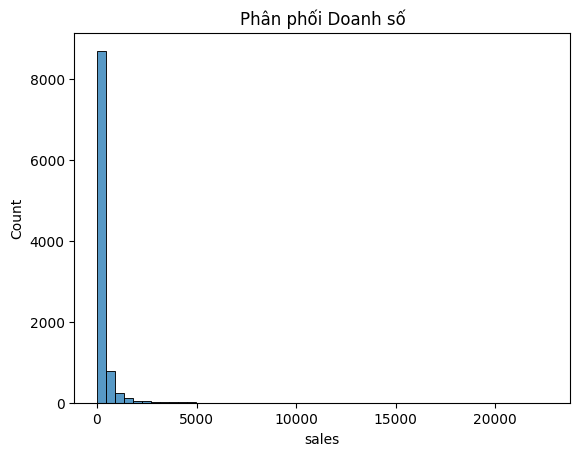

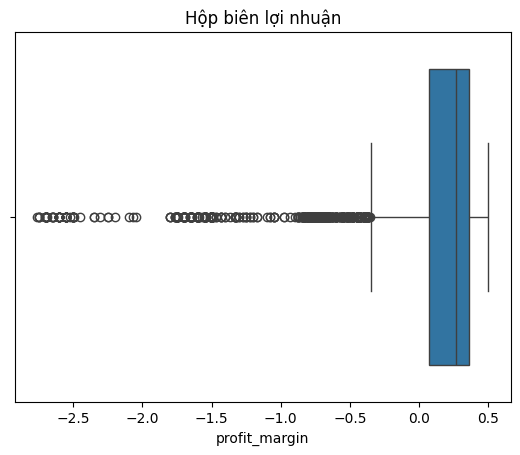

In [3]:
# Thông tin tổng quan
df.info()
df.describe()

# Kiểm tra dữ liệu thiếu
df.isnull().sum()

# Phân phối các biến số
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['sales'], bins=50)
plt.title('Phân phối Doanh số')
plt.show()

# Biên lợi nhuận
sns.boxplot(x=df['profit_margin'])
plt.title('Hộp biên lợi nhuận')
plt.show()

In [4]:
# Theo năm
yearly = df.groupby('order_year').agg({'sales':'sum', 'profit':'sum', 'order_id':'nunique'}).reset_index()
print(yearly)

# Theo vùng
region = df.groupby('region').agg({'sales':'sum', 'profit':'sum', 'customer_id':'nunique'}).reset_index()
print(region)

   order_year      sales    profit  order_id
0        2014  484247.56  49544.06       969
1        2015  470532.46  61618.69      1038
2        2016  609205.86  81795.27      1315
3        2017  733215.19  93439.77      1687
    region      sales     profit  customer_id
0  Central  501239.88   39706.45          629
1     East  678781.36   91522.84          674
2    South  391721.90   46749.71          512
3     West  725457.93  108418.79          686


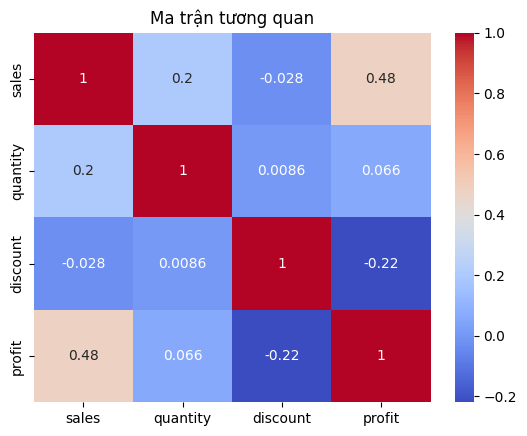

In [5]:
corr = df[['sales', 'quantity', 'discount', 'profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Ma trận tương quan')
plt.show()

In [6]:
# Tính Recency, Frequency, Monetary
import datetime as dt
now = dt.datetime.now()
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (now - x.max()).days,  # recency
    'order_id': 'nunique',                         # frequency
    'sales': 'sum'                                # monetary
}).reset_index()
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Phân loại RFM (dùng phân vị)
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])  # 5 là gần nhất
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])
rfm['rfm_total'] = rfm['r_score'].astype(int) + rfm['f_score'].astype(int) + rfm['m_score'].astype(int)
top_customers = rfm.sort_values('rfm_total', ascending=False).head(20)
print(top_customers)

    customer_id  recency  frequency  monetary r_score f_score m_score  \
35     AI-10855     3181         10   4375.79       5       5       5   
31     AH-10210     3174          9   4805.35       5       5       5   
328    HM-14860     3170         10   8236.76       5       5       5   
365    JG-15160     3169         11   6366.40       5       5       5   
314    GZ-14470     3175          9   4355.15       5       5       5   
82     BF-11170     3184         11   5907.97       5       5       5   
702    SM-20950     3193         12   5563.40       5       5       5   
275    EP-13915     3180         17   5478.06       5       5       5   
683    SE-20110     3177         11  12209.44       5       5       5   
451    LC-16885     3184         12   7663.13       5       5       5   
515    MH-18115     3173          9   5503.09       5       5       5   
233    DR-12880     3171          9   6528.03       5       5       5   
597    PK-19075     3177         12   8646.93      

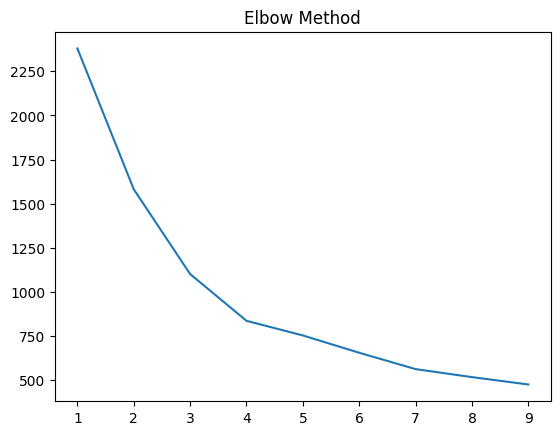

             recency  frequency     monetary  rfm_total
cluster                                                
0        3239.741611   8.516779  3322.223356  11.580537
1        3268.197015   4.731343  1669.688418   7.397015
2        3290.718750   8.296875  9479.546562  12.015625
3        3726.489583   3.697917  1470.228229   4.625000


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Chọn features: recency, frequency, monetary
X = rfm[['recency', 'frequency', 'monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Tìm số cụm tối ưu (Elbow method)
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,10), inertia)
plt.title('Elbow Method')
plt.show()

# Chọn k=4 (ví dụ)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

# Xem đặc trưng từng cụm
print(rfm.groupby('cluster').mean(numeric_only=True))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


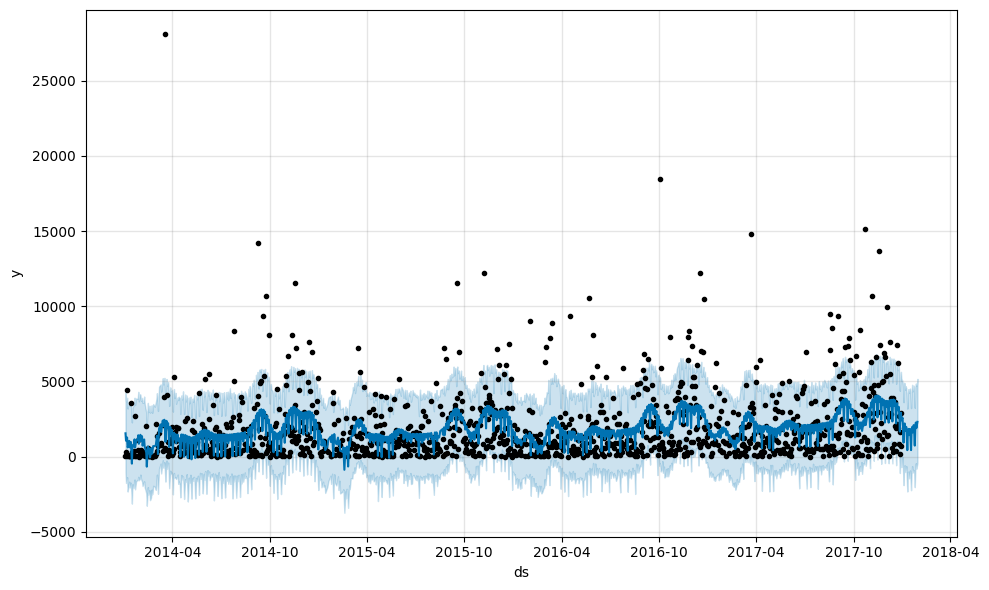

In [9]:
from prophet import Prophet

# Tạo dữ liệu theo ngày
daily_sales = df.groupby('order_date')['sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']

# Huấn luyện mô hình
model = Prophet()
model.fit(daily_sales)

# Dự báo 30 ngày tới
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
model.plot(forecast)
plt.show()

In [10]:
import plotly.express as px

# Doanh số theo vùng và phân khúc
fig = px.bar(df, x='region', y='sales', color='segment', barmode='group', title='Sales by Region and Segment')
fig.show()

# Bản đồ (nếu có tọa độ)
# fig = px.scatter_geo(df, lat='lat', lon='lon', size='sales', hover_name='city')
# fig.show()

In [11]:
fig = px.scatter(df, x='discount', y='profit', color='category', hover_data=['product_name'])
fig.show()

In [13]:
pip install rfm

In [18]:
# Lưu bảng RFM
rfm.to_csv('rfm_customers.csv', index=False)

# Lưu tổng hợp theo vùng, phân khúc, năm
agg = df.groupby(['region', 'segment', 'order_year']).agg({
    'sales':'sum',
    'profit':'sum',
    'order_id':'nunique'
}).reset_index()
agg.to_csv('agg_region_segment_year.csv', index=False)

# Lưu bảng phân cụm khách hàng
rfm_cluster = rfm[['customer_id', 'cluster']]
rfm_cluster.to_csv('customer_clusters.csv', index=False)